# Scaling basic example

## Importing dataset / creating dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [13]:

np.random.seed(42)

# Create a simple linear relationship
f1 = np.arange(1, 41)
f2 = 5 + 1.5 * f1 + np.random.normal(0, 2, 40)


# Linear target with some noise
target = 2 + 3*f1 + 2*f2 + np.random.normal(0, 4, 40)

# Add a few outliers
target[5] = 120
target[15] = 140
target[30] = 160

df = pd.DataFrame({
    'f1': f1,
    'f2': f2,
    'target': target
})

df.head()

,f1,f2,target
0,1,7.493428,22.940723
1,2,7.723471,24.132416
2,3,10.795377,32.128161
3,4,14.046060,40.887705
4,5,12.031693,35.149299


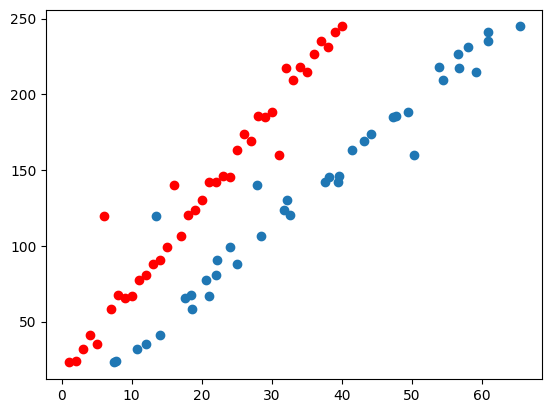

In [14]:
# to confirm whether the relation is linear or non-linear 

import matplotlib.pyplot as plt

plt.scatter(f1,target, color='red')
plt.scatter(f2,target)
plt.show() 

In [15]:
df.corr()

,f1,f2,target
f1,1.000000,0.994202,0.977549
f2,0.994202,1.000000,0.975299
target,0.977549,0.975299,1.000000


## Data preparation

In [16]:
X = df.drop("target", axis = 1) # 2D
# OR 
# X = df[['f1', 'f2']]

X

,f1,f2
0,1,7.493428
1,2,7.723471
2,3,10.795377
3,4,14.046060
4,5,12.031693
5,6,13.531726
6,7,18.658426
7,8,18.534869
8,9,17.561051
9,10,21.085120


In [17]:
y = df["target"]    # 1D
y

0      22.940723
1      24.132416
2      32.128161
3      40.887705
4      35.149299
5     120.000000
6      58.474296
7      67.298228
8      65.496576
9      67.118080
10     77.442665
11     80.596752
12     88.260161
13     90.793584
14     99.224327
15    140.000000
16    106.591805
17    120.020140
18    123.692957
19    130.252966
20    141.945898
21    142.354259
22    145.844773
23    145.516181
24    163.072572
25    173.868650
26    169.107985
27    185.516924
28    185.043989
29    188.252746
30    160.000000
31    217.561259
32    209.802707
33    218.027731
34    214.811199
35    226.404235
36    235.183643
37    230.965290
38    241.054299
39    244.837169
Name: target, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print("X_train shape: ", X_train.shape) # 2d
print("X_test shape: ", X_test.shape)   # 2d
print("y_train shape: ", y_train.shape) # 1d
print("y_test shape: ", y_test.shape)   # 1d

X_train shape:  (32, 2)
X_test shape:  (8, 2)
y_train shape:  (32,)
y_test shape:  (8,)


### Actually we have to start training the model after these , but we will perform scaling then trainig because linear regression will consider larger range values as more important, it wont give proper result

## Scaling techniques

### 1. Standard Scaler

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

updated_x_train = scaler.fit_transform(X_train)  # accepts 2d  # 
updated_x_test = scaler.transform(X_test)   # accepts 2d

updated_x_train[:5]
# updated_x_test

array([[ 1.62712003,  1.68901232],
       [-1.12646771, -0.95691958],
       [ 0.45893129,  0.49036057],
       [-0.87614155, -0.8195316 ],
       [-0.54237334, -0.75791609]])

1. **fit_transform :**
- Accepts only 2D data, should be numeric columns
-  learns the pattern (finds mean and SD ) then transforms the values (based on X_train) of all the fetaure columns within similar range gives equal importance to all the features
- returns data in the form of **_array_**

2. **transform (on test data):**  
- Accepts only 2D data, should be numeric columns
- Applies the founded mean and SD wiht the help of formula to the new test data (transforms the unseen data based on what it has learned previously during fit_trnsform on train dataset)
- returns the data in the form of **_array_**

**NOTE:**
-  If there are more than 2 cols like 4/5/6.... then **fit_transform** finds **_mean_** and **_sd_** for all the cols separately


#### Model training and Evaluation

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train the model
model = LinearRegression()
model.fit(updated_x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
# Predict on train and test
y_train_pred = model.predict(updated_x_train)
y_test_pred = model.predict(updated_x_test)


In [29]:
# Evaluate
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R2: 0.9573329476063307
Test R2: 0.9520330891499595
Train MAE: 7.435260512368551
Test MAE: 8.211660197430302
Train MSE: 200.27685723564434
Test MSE: 155.47104962580252


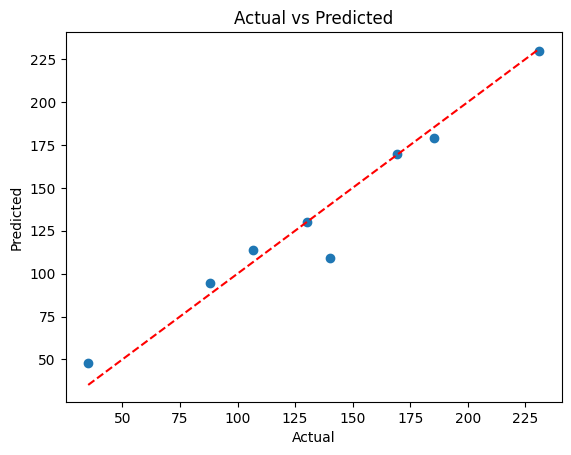

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

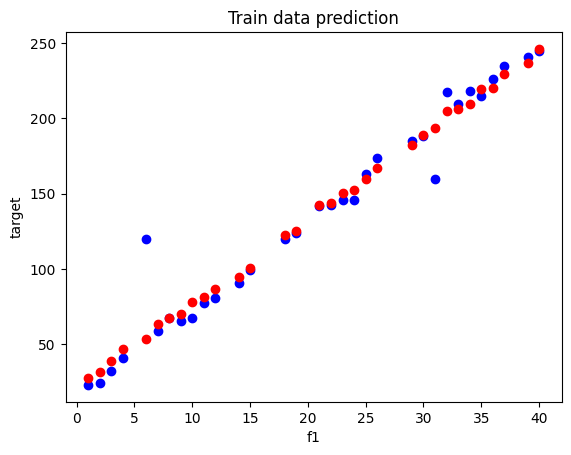

In [43]:
plt.scatter(X_train['f1'], y_train, color="blue")
plt.scatter(X_train['f1'], y_train_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Train data prediction")
plt.show()

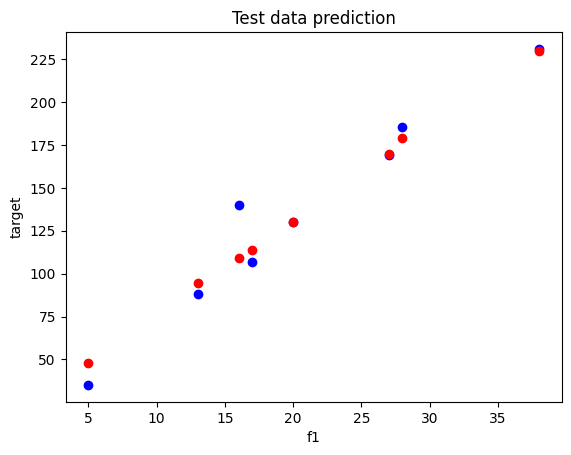

In [41]:
plt.scatter(X_test['f1'], y_test, color="blue")
plt.scatter(X_test['f1'], y_test_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Test data prediction")
plt.show()

### 2. Robust Scaler

In [76]:
from sklearn.preprocessing import RobustScaler

scaler_r = RobustScaler()

updated_xtrain = scaler_r.fit_transform(X_train)
updated_xtest = scaler_r.transform(X_test)

updated_xtrain[:5]
# updated_xtest

array([[ 0.86046512,  0.8856926 ],
       [-0.6744186 , -0.61709332],
       [ 0.20930233,  0.20490524],
       [-0.53488372, -0.53906232],
       [-0.34883721, -0.50406711]])

1. **fit_transform :**
- Accepts only 2D data, should be numeric columns
-  learns the pattern (finds **Q1(25%), Q2(50%), Q3(70%)** medians) then transforms the values **(based on Q2 and IQR)** of all the feature columns within similar range gives equal importance to all the features. 
- > IQR = Q3-Q1
- returns data in the form of **_array_**

2. **transform (on test data):**  
- Accepts only 2D data, should be numeric columns
- Applies the founded **Q2 and IQR** the help of formula to the new test data (transforms the unseen data based on what it has learned previously during fit_transform on train dataset)
- returns the data in the form of **_array_**



#### Model Training and Evaluation

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_r = LinearRegression()

model_r.fit(updated_xtrain, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
# predict on train and test values
ytrain_pred = model_r.predict(updated_xtrain)
ytest_pred = model_r.predict(updated_xtest)


In [97]:
# Evaluate
print("Train R2:", r2_score(y_train, ytrain_pred))
print("Test R2:", r2_score(y_test, ytest_pred))

print("Train MAE:", mean_absolute_error(y_train, ytrain_pred))
print("Test MAE:", mean_absolute_error(y_test, ytest_pred))

print("Train MSE:", mean_squared_error(y_train, ytrain_pred))
print("Test MSE:", mean_squared_error(y_test, ytest_pred))

Train R2: 0.9573329476063307
Test R2: 0.9520330891499595
Train MAE: 7.435260512368557
Test MAE: 8.211660197430303
Train MSE: 200.27685723564437
Test MSE: 155.47104962580255


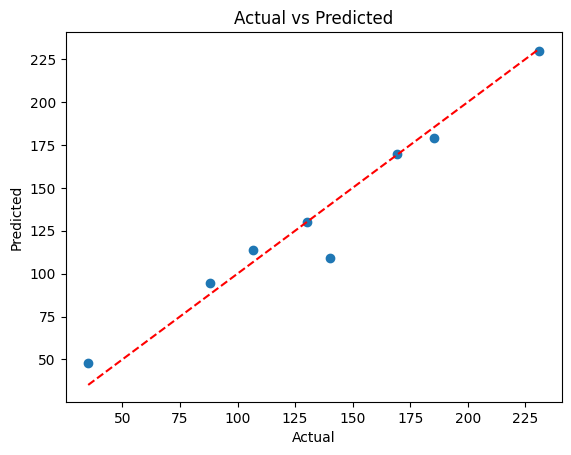

In [98]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

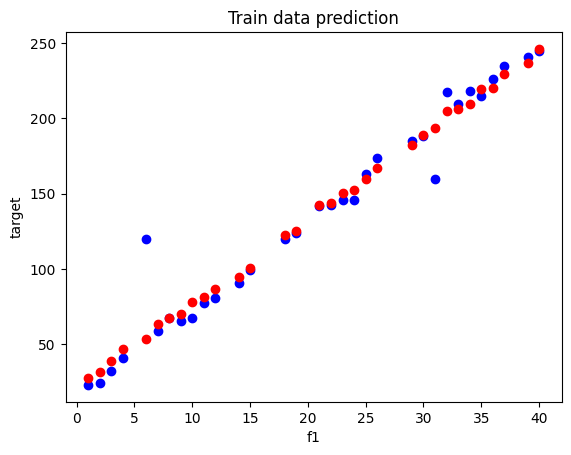

In [99]:
plt.scatter(X_train['f1'], y_train, color="blue")
plt.scatter(X_train['f1'], ytrain_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Train data prediction")
plt.show()

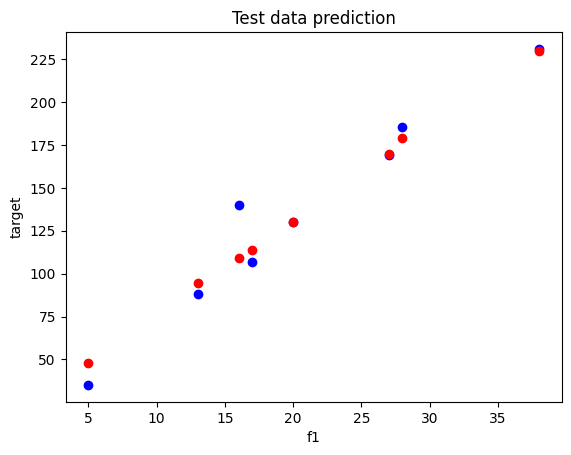

In [100]:
plt.scatter(X_test['f1'], y_test, color="blue")
plt.scatter(X_test['f1'], ytest_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Test data prediction")
plt.show()

### 3. MinMax Scaler

In [77]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

updated_X_train = scaler_mm.fit_transform(X_train)
updated_X_test = scaler_mm.transform(X_test)

updated_X_train[:5]
# updated_X_test

array([[1.        , 1.        ],
       [0.15384615, 0.19283144],
       [0.64102564, 0.63433904],
       [0.23076923, 0.23474305],
       [0.33333333, 0.25353949]])

1. **fit_transform :**
- Accepts only 2D data, should be numeric columns
-  learns the pattern (finds **X(max) and X(min) values**) then transforms the values **(based on X(max) and X(min) values)** what it has learnt and creates new feature columns.
- returns data in the form of **_array_**

2. **transform (on test data):**  
- Accepts only 2D data, should be numeric columns
- Applies the founded **X(max) and X(min)** the help of formula to the new test data transforms the unseen data (Xtest) based on what it has learned previously during fit_transform on train dataset **(X(max) X(min))**
- returns the data in the form of **_array_**



#### Model Training and Evaluation

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_mm = LinearRegression()

model_mm.fit(updated_X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [102]:
# predict on train and test values
yTrain_pred = model_r.predict(updated_X_train)
yTest_pred = model_r.predict(updated_X_test)


In [103]:
# Evaluate
print("Train R2:", r2_score(y_train, yTrain_pred))
print("Test R2:", r2_score(y_test, yTest_pred))

print("Train MAE:", mean_absolute_error(y_train, yTrain_pred))
print("Test MAE:", mean_absolute_error(y_test, yTest_pred))

print("Train MSE:", mean_squared_error(y_train, yTrain_pred))
print("Test MSE:", mean_squared_error(y_test, yTest_pred))

Train R2: -0.16312512218199293
Test R2: -0.5709296259847909
Train MAE: 65.85471311104858
Test MAE: 65.08639247622857
Train MSE: 5459.6469869336
Test MSE: 5091.719969286258


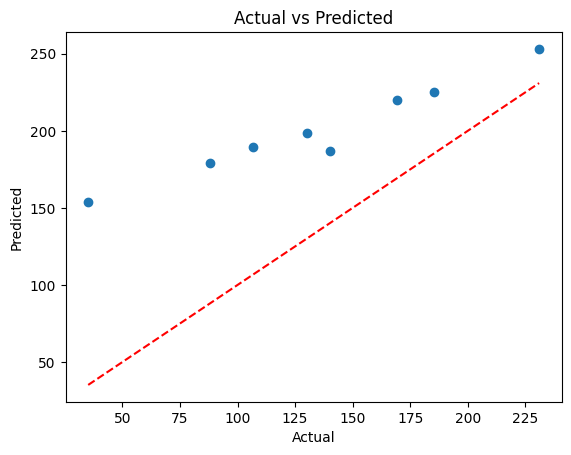

In [104]:
import matplotlib.pyplot as plt

plt.scatter(y_test, yTest_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

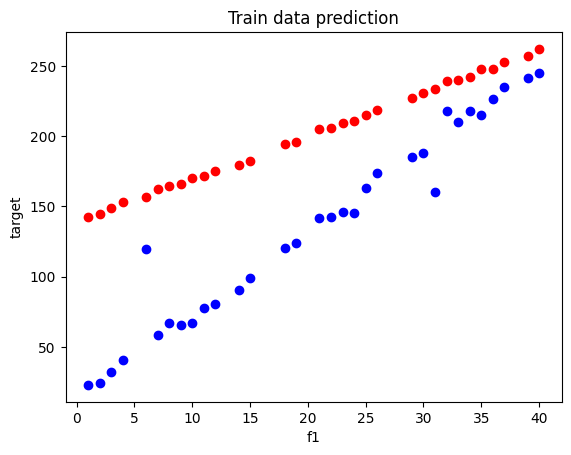

In [105]:
plt.scatter(X_train['f1'], y_train, color="blue")
plt.scatter(X_train['f1'], yTrain_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Train data prediction")
plt.show()

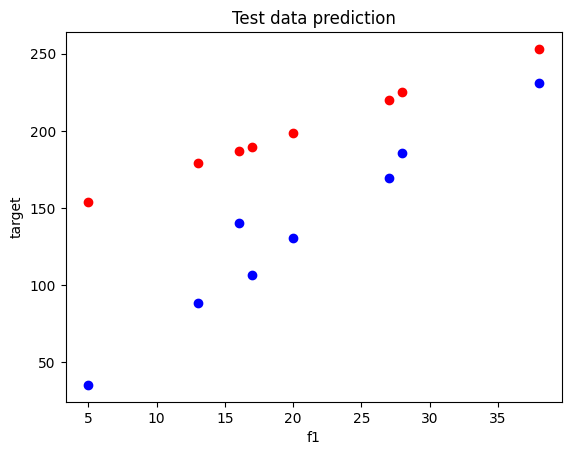

In [107]:
plt.scatter(X_test['f1'], y_test, color="blue")
plt.scatter(X_test['f1'], yTest_pred, color="red")
plt.xlabel("f1")
plt.ylabel("target")
plt.title("Test data prediction")
plt.show()